In [2]:
import scanpy as sc
import harmonypy as hm

In [3]:
adata = sc.read_h5ad("/project/imoskowitz/yubin/1-sc_practice/SmoNull_Brain_system.h5ad")


In [4]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors', 'Celltype'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'mean', 'std'
    uns: 'Celltype_colors', 'ClusterSystem_colors', 'Library.ident_colors', 'X_umap_log1p', 'hvg_log1p', 'neighbors_log1p', 'pca'
    obsm: 'X_pca_harmony_log1p', 'X_pca_log1p', 'X_umap_log1p'
    varm: 'PCs'
    layers: 'analytic_pearson_residuals', 'log1p_norm', 'raw_counts', 'scran_normalization'
    obsp: 'neighbors_log1p_connectivities', 'neighbors_log1p_distances'

# Integration with Pearson Residual Normalization

## Finding Highly Variable Genes 

In [1]:
adata.X = adata.layers["raw_counts"].copy()

NameError: name 'adata' is not defined

In [ ]:
# Using experimental that allow for pearson_residual flavors
sc.experimental.pp.highly_variable_genes(adata, flavor="pearson_residuals", batch_key="Library.ident", n_top_genes=2000)

In [9]:
# Remember to switch to pearson
adata.X = adata.layers["analytic_pearson_residuals"]

In [10]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors'
    var: 'features', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable'
    uns: 'ClusterSystem_colors', 'Library.ident_colors', 'X_umap_log1p', 'hvg', 'neighbors_log1p', 'pca'
    obsm: 'X_pca_harmony_log1p', 'X_pca_log1p', 'X_umap_log1p'
    varm: 'PCs'
    layers: 'analytic_pearson_residuals', 'log1p_nor

In [11]:
sc.pp.pca(adata)

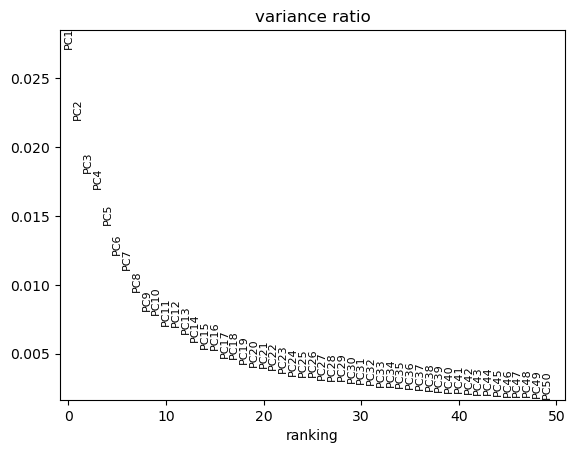

In [12]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=False)

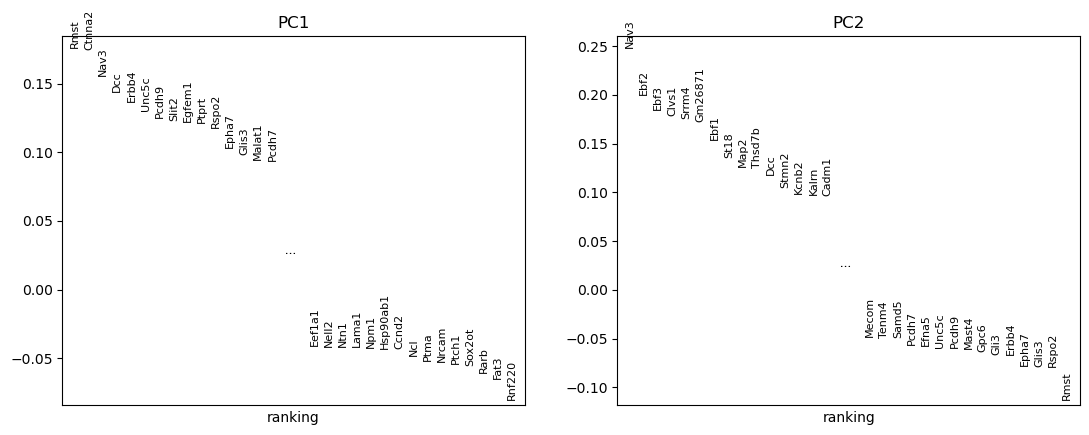

In [15]:
sc.pl.pca_loadings(adata, components = [1,2], show = True)

In [13]:
adata.obsm["X_pca_pearson"] = adata.obsm["X_pca"][:, :13]
del adata.obsm["X_pca"]

In [14]:
sc.external.pp.harmony_integrate(adata, key="Library.ident", max_iter_harmony=20, basis = "X_pca_pearson")

2026-03-10 14:00:44,093 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-10 14:00:47,239 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-10 14:00:47,399 - harmonypy - INFO - Iteration 1 of 20
2026-03-10 14:00:54,528 - harmonypy - INFO - Iteration 2 of 20
2026-03-10 14:01:01,674 - harmonypy - INFO - Iteration 3 of 20
2026-03-10 14:01:08,870 - harmonypy - INFO - Iteration 4 of 20
2026-03-10 14:01:16,103 - harmonypy - INFO - Iteration 5 of 20
2026-03-10 14:01:23,290 - harmonypy - INFO - Iteration 6 of 20
2026-03-10 14:01:30,455 - harmonypy - INFO - Iteration 7 of 20
2026-03-10 14:01:32,420 - harmonypy - INFO - Iteration 8 of 20
2026-03-10 14:01:34,376 - harmonypy - INFO - Converged after 8 iterations


In [37]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors', 'Celltype'
    var: 'features', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable'
    uns: 'ClusterSystem_colors', 'Library.ident_colors', 'X_umap_log1p', 'hvg', 'neighbors_log1p', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca_harmony_log1p', 'X_pca_log1p', 'X_umap_log1p', 'X_pca_pearson', 'X_pca_harmony', 

In [18]:
sc.pp.neighbors(adata, use_rep="X_pca_harmony")

/home/yubin/.conda/envs/scRNAseq_python/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
sc.tl.umap(adata)

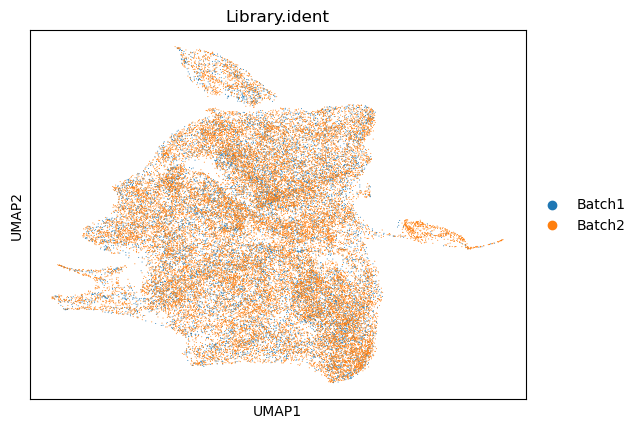

In [23]:
sc.pl.umap(adata, color = "Library.ident", size = 2)

In [27]:
celltype = pd.read_csv("/project/imoskowitz/yubin/1-sc_practice/Preprocessing/Integration/Actual Integration/celltype.csv")

In [33]:
type(celltype)

pandas.core.frame.DataFrame

In [31]:
celltype.set_index("Unnamed: 0", inplace = True)

In [34]:
celltype.index

Index(['Sample1_Control_rep1_AAACCAAAGAATCAAG-1',
       'Sample1_Control_rep1_AAACCAAAGATTGACT-1',
       'Sample1_Control_rep1_AAACCATTCAGCAGGA-1',
       'Sample1_Control_rep1_AAACCCGCAATGCCAG-1',
       'Sample1_Control_rep1_AAACCCGCAGCACTTC-1',
       'Sample1_Control_rep1_AAACCCGCATGGTCAG-1',
       'Sample1_Control_rep1_AAACCCTGTAGTCCGC-1',
       'Sample1_Control_rep1_AAACCCTGTGGCGCTT-1',
       'Sample1_Control_rep1_AAACCGCTCCACCGGA-1',
       'Sample1_Control_rep1_AAACCGCTCCAGGCCA-1',
       ...
       'Sample6_SmoNull_rep3_TGTGCTGGTGGCTCAC-1',
       'Sample6_SmoNull_rep3_TGTGGTCAGCATTACG-1',
       'Sample6_SmoNull_rep3_TGTGGTCAGTGTCCGG-1',
       'Sample6_SmoNull_rep3_TGTGGTTGTAGTGCCC-1',
       'Sample6_SmoNull_rep3_TGTGGTTGTGAGGTCG-1',
       'Sample6_SmoNull_rep3_TGTGGTTGTGCGGCTT-1',
       'Sample6_SmoNull_rep3_TGTGTACGTCAAGTCT-1',
       'Sample6_SmoNull_rep3_TGTGTACGTTCCGTTC-1',
       'Sample6_SmoNull_rep3_TGTGTTGAGCAGGTAG-1',
       'Sample6_SmoNull_rep3_TGTGTTGAGT

In [35]:
adata.obs = adata.obs.merge(celltype, left_index=True, right_index=True, how = "outer")

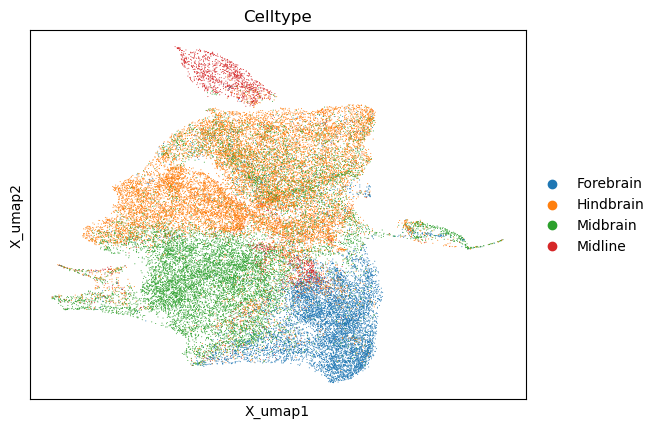

In [38]:
sc.pl.embedding(adata, basis = "X_umap", color = "Celltype", size = 2)